In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df=pd.read_csv("housing.csv")

In [5]:
df.head(10)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
5,-122.25,37.85,52.0,919.0,213.0,413.0,193.0,4.0368,269700.0,NEAR BAY
6,-122.25,37.84,52.0,2535.0,489.0,1094.0,514.0,3.6591,299200.0,NEAR BAY
7,-122.25,37.84,52.0,3104.0,687.0,1157.0,647.0,3.1200,241400.0,NEAR BAY
8,-122.26,37.84,42.0,2555.0,665.0,1206.0,595.0,2.0804,226700.0,NEAR BAY
9,-122.25,37.84,52.0,3549.0,707.0,1551.0,714.0,3.6912,261100.0,NEAR BAY


In [6]:
df.shape

(20640, 10)

In [7]:
df.columns


Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='str')

In [8]:
df.isna().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [9]:
for col in df.columns:
    print(df[col].value_counts().head(20))
 

longitude
-118.31    162
-118.30    160
-118.29    148
-118.27    144
-118.32    142
-118.28    141
-118.35    140
-118.36    138
-118.19    135
-118.37    128
-118.25    128
-118.20    126
-118.14    125
-118.26    121
-118.13    121
-118.18    120
-118.34    119
-118.21    118
-118.15    116
-118.12    112
Name: count, dtype: int64
latitude
34.06    244
34.05    236
34.08    234
34.07    231
34.04    221
34.09    212
34.02    208
34.10    203
34.03    193
33.93    181
33.94    175
33.97    172
33.99    168
33.88    164
34.11    162
33.98    162
34.16    159
34.12    158
34.15    157
34.01    156
Name: count, dtype: int64
housing_median_age
52.0    1273
36.0     862
35.0     824
16.0     771
17.0     698
34.0     689
26.0     619
33.0     615
18.0     570
25.0     566
32.0     565
37.0     537
15.0     512
19.0     502
27.0     488
24.0     478
30.0     476
28.0     471
20.0     465
29.0     461
Name: count, dtype: int64
total_rooms
1527.0    18
1613.0    17
1582.0    17
2127.0    16


In [10]:
df['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

<Axes: xlabel='ocean_proximity', ylabel='count'>

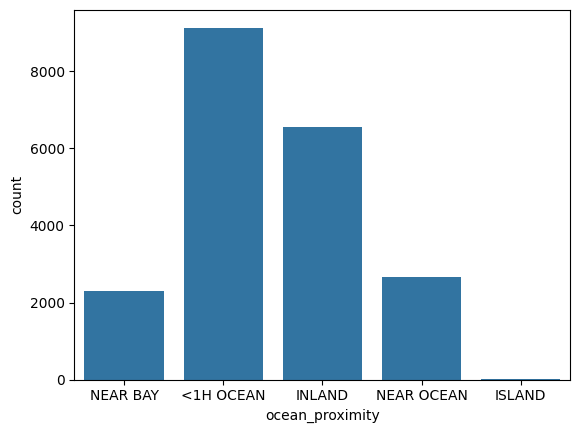

In [11]:
sns.countplot(x="ocean_proximity",data=df)

In [12]:
df['median_house_value'].max()

np.float64(500001.0)

<Axes: xlabel='median_house_value', ylabel='Count'>

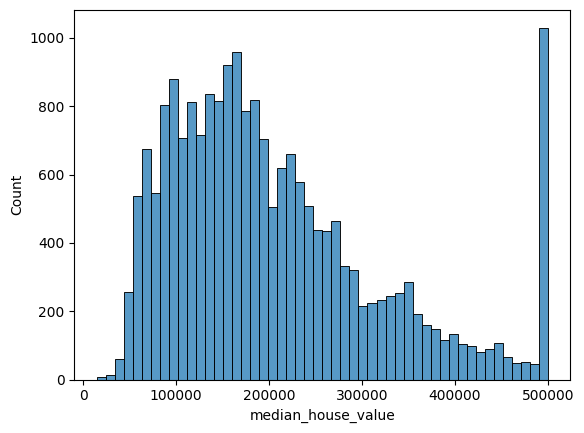

In [13]:
sns.histplot(df['median_house_value'],bins=50)

In [31]:
num_cols = df.select_dtypes(include='number').columns
cat_cols= df.select_dtypes(include='object').columns

C:\Users\chand\AppData\Local\Temp\ipykernel_1996\3407986146.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols= df.select_dtypes(include='object').columns


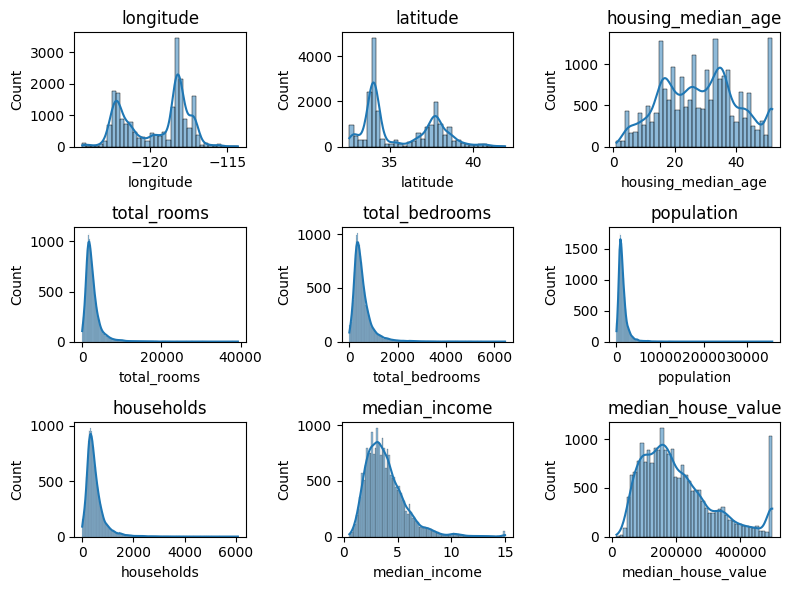

In [21]:
fig, axes = plt.subplots(3, 3, figsize=(8, 6))
axes = axes.flatten()
for i,col in enumerate(num_cols):
    sns.histplot(df[col],kde=True,ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
    


In [ ]:
# Key Insights from EDA
# Dataset has numeric + one categorical feature (ocean_proximity)
# Only total_bedrooms has missing values
# Target (median_house_value) is right-skewed and capped
# Several features show strong skew and outliers
# median_income is the strongest predictor
# High multicollinearity among room and population features

In [ ]:
# Preprocessing & Evaluation Plan
# Median imputation for missing values
# One-hot encoding for categorical feature
# Feature scaling for linear models
# Use pipelines to avoid data leakage
# Baseline model → CV model selection → hyperparameter tuning
# Primary metric: RMSE, secondary: MAE and R²
# Final evaluation only on test set

In [25]:
X=df.drop(columns=['median_house_value'])
Y=df['median_house_value']

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y,test_size=0.2,random_state=42)

In [30]:
X_train.shape


(16512, 9)

In [ ]:
# No Order  → OneHotEncoder -> like ocean proximity
# Has Order → OrdinalEncoder ->like good , bad , worst that has order
# Numbers   → Scale (StandardScaler)

In [40]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
# Numerical columns
number_cols = X.select_dtypes(include='number').columns

# Categorical columns
category_cols = X.select_dtypes(include='object').columns

# Numerical pipeline
numerical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

# Categorical pipeline
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)
#pre processing pipeline
preprocess = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, number_cols),
        ("cat", categorical_transformer, category_cols)
    ]
)


C:\Users\chand\AppData\Local\Temp\ipykernel_1996\3758755526.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  category_cols = X.select_dtypes(include='object').columns


In [41]:
from sklearn.linear_model import LinearRegression
baseline_pipe = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", LinearRegression())
    ]
)

In [42]:
baseline_pipe.fit(X_train, Y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [43]:
train_baseline_pred = baseline_pipe.predict(X_train)

test_baseline_pred = baseline_pipe.predict(X_test)

In [44]:
train_baseline_pred [:5]

array([188628.07724361, 290379.8948687 , 250985.48476349, 146878.07878194,
       165789.41368924])

In [45]:
Y_train[:5]

14196    103000.0
8267     382100.0
17445    172600.0
14265     93400.0
2271      96500.0
Name: median_house_value, dtype: float64

In [ ]:
# Training predictions are usually better than test predictions because the model has already seen the training data. However,
# they are not always identical. Models such as Linear Regression learn general patterns rather than memorizing every training example.
# If a model predicts the training data perfectly, it may indicate overfitting, where the model memorizes the data instead of learning patterns
# that generalize to unseen examples.

In [46]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [48]:
train_rmse = np.sqrt(mean_squared_error(Y_train, train_baseline_pred))
train_mae = mean_absolute_error(Y_train, train_baseline_pred)
train_r2 = r2_score(Y_train, train_baseline_pred)

In [52]:
print(f"Train RMSE: {train_rmse:.2f}")
print(f"Train MAE : {train_mae:.2f}")
print(f"Train R2  : {train_r2:.4f}")

Train RMSE: 68433.94
Train MAE : 49594.84
Train R2  : 0.6497


In [49]:
test_rmse = np.sqrt(mean_squared_error(Y_test, test_baseline_pred))
test_mae = mean_absolute_error(Y_test, test_baseline_pred)
test_r2 = r2_score(Y_test, test_baseline_pred)

In [53]:
print(f"Test RMSE: {test_rmse:.2f}")
print(f"Test MAE : {test_mae:.2f}")
print(f"Test R2  : {test_r2:.4f}")

Test RMSE: 70059.19
Test MAE : 50670.49
Test R2  : 0.6254


In [ ]:
# if your data is around 1million , 10 million then this error is small and its good , we should always compare it with data 